# Exercise 00 : Line chart




In [1]:
import pandas as pd
import sqlite3

data = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
query = """
SELECT datetime FROM pageviews
WHERE uid LIKE 'user_%'
"""

df = pd.read_sql_query(query, data)

data.close()

df

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


## Подготавливаем данные для графика



In [3]:
df['date'] = pd.to_datetime(df['datetime']).dt.date

df_grouped = df.groupby('date').size().reset_index(name='views')
df_grouped

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


## Выводим график



<Axes: title={'center': 'Views per day'}, xlabel='date'>

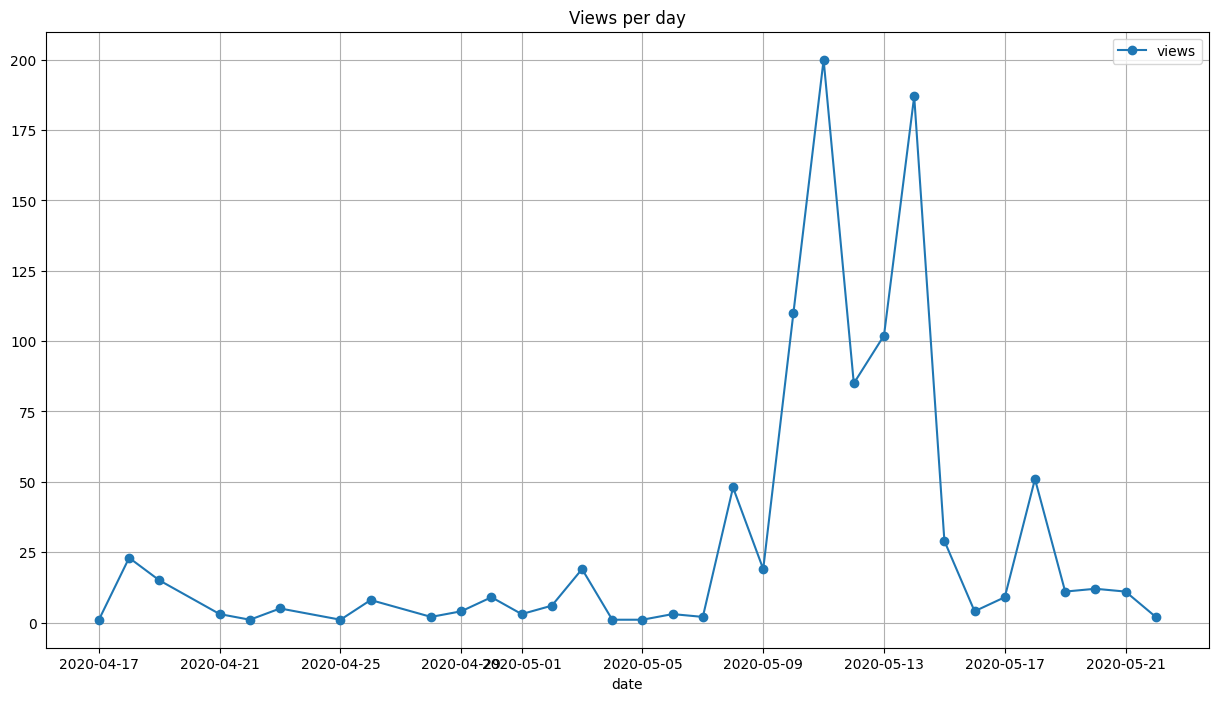

In [4]:
df_grouped.plot(
    x='date', 
    y='views', 
    kind='line', 
    marker='o', 
    linestyle='-', 
    figsize=(15, 8), 
    title='Views per day', 
    grid=True
)